In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

In [18]:
print("=" * 60)
print("CAREERPATH AI RECOMMENDER")
print("Project 3 - DecodeLabs")
print("=" * 60)

CAREERPATH AI RECOMMENDER
Project 3 - DecodeLabs


In [19]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [20]:
career_data = {
    "Career": [

        "Data Scientist",
        "Data Analyst",
        "Business Analyst",

        "AI Engineer",
        "Machine Learning Engineer",
        "Deep Learning Engineer",

        "Backend Developer",
        "Frontend Developer",
        "Full Stack Developer",

        "DevOps Engineer",
        "Cloud Engineer",
        "Site Reliability Engineer",

        "Cybersecurity Analyst",
        "Security Engineer",
        "Ethical Hacker",

        "Mobile App Developer",
        "Android Developer",
        "iOS Developer",

        "Game Developer",
        "AR VR Developer",

        "Database Administrator",
        "Data Engineer",

        "Software Engineer",
        "Java Developer",
        "Python Developer",

        "Blockchain Developer",
        "Web3 Developer",

        "UI UX Designer",

        "Product Manager",

        "QA Engineer",
        "Automation Test Engineer"
    ],

    "Skills": [

        "python sql machine learning statistics pandas numpy",
        "sql excel power bi python visualization analytics",
        "sql excel power bi business analytics communication",

        "python machine learning deep learning tensorflow pytorch",
        "python machine learning sklearn ai statistics",
        "python deep learning neural networks tensorflow pytorch",

        "java spring boot mysql sql rest api git",
        "html css javascript react ui ux",
        "html css javascript react nodejs express mongodb",

        "aws docker kubernetes linux ci cd devops",
        "aws azure cloud docker kubernetes linux",
        "linux docker kubernetes monitoring automation",

        "network security cybersecurity linux siem",
        "security cloud security network security linux",
        "ethical hacking kali penetration testing cybersecurity",

        "java kotlin android mobile app development",
        "java kotlin android firebase xml",
        "swift ios mobile development xcode",

        "unity csharp game development graphics",
        "unity unreal engine vr ar csharp",

        "sql mysql postgresql database administration",
        "python sql etl big data spark hadoop",

        "java python c++ dsa oop git",
        "java spring boot mysql backend development",
        "python django flask api development",

        "solidity blockchain smart contracts ethereum",
        "blockchain ethereum web3 solidity defi",

        "figma ui ux wireframing prototyping design",

        "communication management agile leadership analytics",

        "testing manual testing bug tracking qa",
        "selenium java automation testing qa"
    ]
}

df = pd.DataFrame(career_data)

print("Total Careers:", len(df))
df.head()

Total Careers: 31


,Career,Skills
0,Data Scientist,python sql machine learning statistics pandas ...
1,Data Analyst,sql excel power bi python visualization analytics
2,Business Analyst,sql excel power bi business analytics communic...
3,AI Engineer,python machine learning deep learning tensorfl...
4,Machine Learning Engineer,python machine learning sklearn ai statistics


In [21]:
print("=" * 60)
print("CAREER DATASET INFORMATION")
print("=" * 60)

print("\nTotal Career Paths:", len(df))

print("\nCareer List:\n")

for career in df["Career"]:
    print("•", career)

CAREER DATASET INFORMATION

Total Career Paths: 31

Career List:

• Data Scientist
• Data Analyst
• Business Analyst
• AI Engineer
• Machine Learning Engineer
• Deep Learning Engineer
• Backend Developer
• Frontend Developer
• Full Stack Developer
• DevOps Engineer
• Cloud Engineer
• Site Reliability Engineer
• Cybersecurity Analyst
• Security Engineer
• Ethical Hacker
• Mobile App Developer
• Android Developer
• iOS Developer
• Game Developer
• AR VR Developer
• Database Administrator
• Data Engineer
• Software Engineer
• Java Developer
• Python Developer
• Blockchain Developer
• Web3 Developer
• UI UX Designer
• Product Manager
• QA Engineer
• Automation Test Engineer


In [22]:
print("\nEnter at least 3 skills.")

user_skills = input(
    "\nEnter skills separated by commas: "
)

user_skills = user_skills.lower()

print("\nYour Skills:")
print(user_skills)


Enter at least 3 skills.



Enter skills separated by commas:  java, dsa, oop, c, c++, python, html, css



Your Skills:
java, dsa, oop, c, c++, python, html, css


In [23]:
all_text = df["Skills"].tolist()

all_text.append(user_skills)

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(all_text)

print("✓ TF-IDF Vectorization Complete")

print("\nMatrix Shape:", tfidf_matrix.shape)

✓ TF-IDF Vectorization Complete

Matrix Shape: (32, 107)


In [24]:
user_vector = tfidf_matrix[-1]

career_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(
    user_vector,
    career_vectors
)

similarity_scores = similarity_scores.flatten()

print("✓ Similarity Scores Generated")

✓ Similarity Scores Generated


In [25]:
df["Match Score"] = similarity_scores * 100

recommendations = df.sort_values(
    by="Match Score",
    ascending=False
)

recommendations["Match Score"] = (
    recommendations["Match Score"]
    .round(2)
)

recommendations.head(10)

,Career,Skills,Match Score
22,Software Engineer,java python c++ dsa oop git,68.82
7,Frontend Developer,html css javascript react ui ux,32.80
8,Full Stack Developer,html css javascript react nodejs express mongodb,28.66
30,Automation Test Engineer,selenium java automation testing qa,11.01
16,Android Developer,java kotlin android firebase xml,10.54
23,Java Developer,java spring boot mysql backend development,10.32
15,Mobile App Developer,java kotlin android mobile app development,10.16
24,Python Developer,python django flask api development,9.11
6,Backend Developer,java spring boot mysql sql rest api git,8.82
4,Machine Learning Engineer,python machine learning sklearn ai statistics,8.30


In [26]:
print("=" * 60)
print("TOP 5 CAREER RECOMMENDATIONS")
print("=" * 60)

top5 = recommendations.head(5)

for i, row in enumerate(
    top5.itertuples(index=False),
    start=1
):
    print(
        f"{i}. {row.Career}  -->  {row[-1]:.2f}% Match"
    )

TOP 5 CAREER RECOMMENDATIONS
1. Software Engineer  -->  68.82% Match
2. Frontend Developer  -->  32.80% Match
3. Full Stack Developer  -->  28.66% Match
4. Automation Test Engineer  -->  11.01% Match
5. Android Developer  -->  10.54% Match


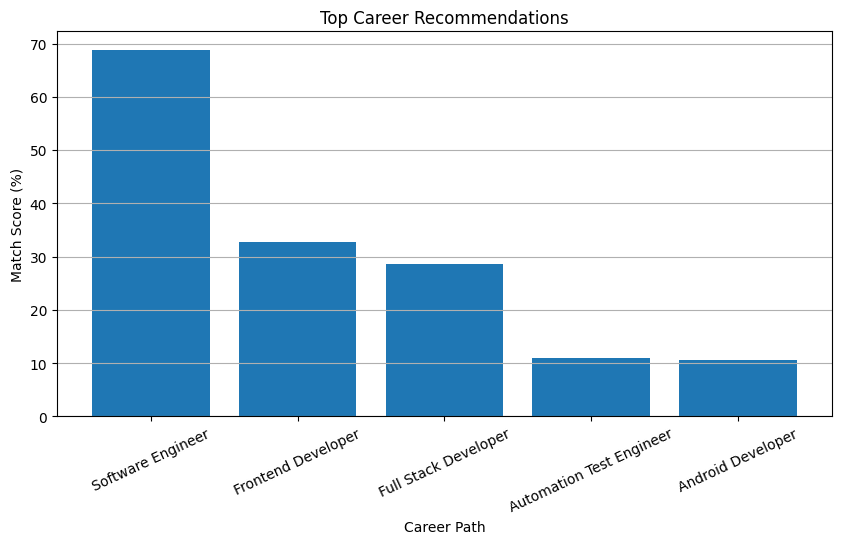

In [27]:
plt.figure(figsize=(10,5))

plt.bar(
    top5["Career"],
    top5["Match Score"]
)

plt.title(
    "Top Career Recommendations"
)

plt.xlabel("Career Path")

plt.ylabel("Match Score (%)")

plt.xticks(rotation=25)

plt.grid(axis="y")

plt.show()

In [28]:
best_match = recommendations.iloc[0]

print("=" * 60)
print("BEST CAREER MATCH")
print("=" * 60)

print(
    "\nCareer:",
    best_match["Career"]
)

print(
    "Match Score:",
    f"{best_match['Match Score']:.2f}%"
)

BEST CAREER MATCH

Career: Software Engineer
Match Score: 68.82%


In [29]:
career_skills = set(
    best_match["Skills"].split()
)

user_skill_set = set(
    skill.strip()
    for skill in user_skills.split(",")
)

missing_skills = (
    career_skills - user_skill_set
)

print("\nRecommended Skills To Learn:\n")

for skill in sorted(missing_skills):
    print("•", skill)


Recommended Skills To Learn:

• git


In [30]:
matching_skills = (
    career_skills.intersection(
        user_skill_set
    )
)

print("\nSkills You Already Have:\n")

for skill in sorted(matching_skills):
    print("✓", skill)


Skills You Already Have:

✓ c++
✓ dsa
✓ java
✓ oop
✓ python


In [31]:
print("\n" + "=" * 60)
print("RECOMMENDATION SUMMARY")
print("=" * 60)

print(
    f"\nBest Career Match: {best_match['Career']}"
)

print(
    f"Match Score: {best_match['Match Score']:.2f}%"
)

print(
    f"\nTotal Career Paths Analyzed: {len(df)}"
)

print(
    f"Top Recommendation Count: {len(top5)}"
)

print("\nCareer Recommendation Completed Successfully.")


RECOMMENDATION SUMMARY

Best Career Match: Software Engineer
Match Score: 68.82%

Total Career Paths Analyzed: 31
Top Recommendation Count: 5

Career Recommendation Completed Successfully.


In [32]:
history = recommendations.head(10)[
    ["Career", "Match Score"]
]

print("\nTop 10 Ranked Careers:\n")

display(history)


Top 10 Ranked Careers:



,Career,Match Score
22,Software Engineer,68.82
7,Frontend Developer,32.80
8,Full Stack Developer,28.66
30,Automation Test Engineer,11.01
16,Android Developer,10.54
23,Java Developer,10.32
15,Mobile App Developer,10.16
24,Python Developer,9.11
6,Backend Developer,8.82
4,Machine Learning Engineer,8.30
